In [ ]:
import random
from random import randint
import matplotlib.pyplot as plt

In [ ]:
# Dice utilities
def roll_die(sides):
    return randint(1, sides)

def roll_ndm(n, m):
    return sum(roll_die(m) for _ in range(n))

def roll_d20():
    return roll_die(20)

In [ ]:
# Character model

class Character:
    def __init__(
        self,
        name,
        max_hp,
        ac,
        atk_bonus,
        normal_dmg,
        heavy_dmg=None,
        protection_cd_max=0,
        heavy_cd_max=0
    ):

        #  Configured Attributes
        self.name = name
        self.max_hp = max_hp
        self.ac = ac
        self.atk_bonus = atk_bonus
        self.normal_dmg = normal_dmg
        self.heavy_dmg = heavy_dmg
        self.protection_cd_max = protection_cd_max
        self.heavy_cd_max = heavy_cd_max

        # Internal State
        self.hp = max_hp
        self.alive = True
        self.protection_active = False
        self.protection_cd_remaining = 0
        self.heavy_cd_remaining = 0

        # Statistics Tracking (For the Monte Carlo Report)
        self.attacks = 0
        self.hits = 0
        self.dmg_dealt = 0
        self.dmg_taken = 0
        self.protections_cast = 0
        self.heavy_used = 0

    def reset(self):
        """Resets character to starting state for a new simulation duel"""
        self.hp = self.max_hp
        self.alive = True
        self.protection_active = False
        self.protection_cd_remaining = 0
        self.heavy_cd_remaining = 0

        # Reset counters
        self.attacks = 0
        self.hits = 0
        self.dmg_dealt = 0
        self.dmg_taken = 0
        self.protections_cast = 0
        self.heavy_used = 0

In [ ]:
# Mechanics
def roll_initiative_order(a, b):
    """Initiative once per battle (d20 each, reroll ties)"""
    while True:
        ia, ib = roll_d20(), roll_d20()
        if ia != ib:
            return [a, b] if ia > ib else [b, a]

def decrement_round_cooldowns(chars):
    """Cooldowns in rounds, so decrement once after both have acted"""
    for c in chars:
        if c.protection_cd_remaining > 0:
            c.protection_cd_remaining -= 1
        if c.heavy_cd_remaining > 0:
            c.heavy_cd_remaining -= 1

def can_cast_protection(mage):
    return (
        mage.protection_cd_max > 0
        and mage.protection_cd_remaining == 0
        and mage.protection_active == False
    )

def cast_protection(mage):
    """
    Protection: applies to next incoming hit
    If next incoming attack hits, its damage is halved, then expires
    Cooldown starts when cast
    """
    mage.protection_active = True
    mage.protection_cd_remaining = mage.protection_cd_max
    mage.protections_cast += 1

def roll_damage(dmg_profile):
    n, m, bonus = dmg_profile
    return roll_ndm(n, m) + bonus

def resolve_attack(attacker, defender, dmg_profile, atk_bonus_override = None):
    """Attack: d20+AtkBonus >= AC hits; roll damage; apply protection halving (if active)"""
    attacker.attacks += 1

    d20 = roll_d20()
    atk_bonus_used = attacker.atk_bonus if atk_bonus_override is None else atk_bonus_override
    total = d20 + atk_bonus_used
    hit = total >= defender.ac

    if not hit:
        return {"action": "attack", "hit": False, "d20": d20, "total": total}

    attacker.hits += 1
    raw = roll_damage(dmg_profile)

    if defender.protection_active:
        dmg = raw // 2
        defender.protection_active = False
        protected = True
    else:
        dmg = raw
        protected = False

    defender.hp -= dmg
    attacker.dmg_dealt += dmg
    defender.dmg_taken += dmg

    if defender.hp <= 0:
        defender.hp = 0
        defender.alive = False

    return {
        "action": "attack",
        "hit": True,
        "d20": d20,
        "total": total,
        "raw_damage": raw,
        "damage": dmg,
        "protected": protected,
    }

In [ ]:
# Policies
def magician_policy(mage, paladin, hp_threshold = 0.60) :
    """
    If Protection off cooldown AND not active AND (HP ≤ 60% OR Paladin heavy available) -> Protection
    Else -> Attack
    """
    hp_ratio = mage.hp / mage.max_hp
    paladin_heavy_available = (paladin.heavy_cd_remaining == 0)
    if can_cast_protection(mage) and (hp_ratio <= hp_threshold or paladin_heavy_available):
        return "protection"
    return "attack"

def paladin_policy(paladin) :
    """If Heavy off cooldown -> Heavy else Normal attack"""
    return "heavy" if paladin.heavy_cd_remaining == 0 else "attack"

In [ ]:
# Duel simulation (2 players)
def simulate_duel(config, max_rounds=15, magician_hp_threshold=0.60):

    mage = Character(
        name="Magician",
        max_hp=config["magician"]["hp"],
        ac=config["magician"]["ac"],
        atk_bonus=config["magician"]["atk_bonus"],
        normal_dmg=config["magician"]["attack_dmg"],  # attack spell
        protection_cd_max=config["magician"]["protection_cd"],
    )
    pal = Character(
        name="Paladin",
        max_hp=config["paladin"]["hp"],
        ac=config["paladin"]["ac"],
        atk_bonus=config["paladin"]["atk_bonus"],
        normal_dmg=config["paladin"]["attack_dmg"],
        heavy_dmg=config["paladin"]["heavy_dmg"],
        heavy_cd_max=config["paladin"]["heavy_cd"],
    )

    mage.reset()
    pal.reset()

    order = roll_initiative_order(mage, pal)
    rounds = 0

    while rounds < max_rounds and mage.alive and pal.alive:
        rounds += 1

        # Both act once per round (initiative order)
        for actor in order:
            if not mage.alive or not pal.alive:
                break

            opponent = pal if actor is mage else mage

            if actor is mage:
                decision = magician_policy(mage, pal, hp_threshold=magician_hp_threshold)
                if decision == "protection":
                    cast_protection(mage)
                else:
                    resolve_attack(mage, pal, mage.normal_dmg)
            else:
                decision = paladin_policy(pal)
                if decision == "heavy":
                    pal.heavy_used += 1
                    pal.heavy_cd_remaining = pal.heavy_cd_max
                    resolve_attack(pal, mage, pal.heavy_dmg, atk_bonus_override=pal.atk_bonus - 2)
                else:
                    resolve_attack(pal, mage, pal.normal_dmg)

        # End-of-round cooldown tick
        decrement_round_cooldowns([mage, pal])

    if mage.alive and not pal.alive:
        winner = "Magician"
    elif pal.alive and not mage.alive:
        winner = "Paladin"
    elif mage.alive and pal.alive:
        winner = "Timeout"
    else:
        winner = "No one"

    return {
        "winner": winner,
        "rounds": rounds,
        "initiative_first": order[0].name,
        "magician": {
            "hp_end": mage.hp,
            "attacks": mage.attacks,
            "hits": mage.hits,
            "dmg_dealt": mage.dmg_dealt,
            "dmg_taken": mage.dmg_taken,
            "protections_cast": mage.protections_cast,
        },
        "paladin": {
            "hp_end": pal.hp,
            "attacks": pal.attacks,
            "hits": pal.hits,
            "dmg_dealt": pal.dmg_dealt,
            "dmg_taken": pal.dmg_taken,
            "heavy_used": pal.heavy_used,
        },
    }

In [ ]:
# Monte Carlo runner
def run_monte_carlo(n_sims, config, max_rounds=30, magician_hp_threshold=0.60):
    winners = []
    rounds_list = []
    protections_list = []
    heavy_list = []

    for _ in range(n_sims):
        res = simulate_duel(
            config=config,
            max_rounds=max_rounds,
            magician_hp_threshold=magician_hp_threshold
        )
        winners.append(res["winner"])
        rounds_list.append(res["rounds"])
        protections_list.append(res["magician"]["protections_cast"])
        heavy_list.append(res["paladin"]["heavy_used"])

    return {
        "n_sims": n_sims,
        "win_rates": {
            "Magician": winners.count("Magician") / n_sims,
            "Paladin": winners.count("Paladin") / n_sims,
            "Timeout": winners.count("Timeout") / n_sims,
            "No one": winners.count("No one") / n_sims
        },
        "avg_rounds": sum(rounds_list) / n_sims,
        "avg_magician_protections": sum(protections_list) / n_sims,
        "avg_paladin_heavy_used": sum(heavy_list) / n_sims
    }

In [ ]:
# Baseline configuration
BASE_CONFIG = {
    "magician": {
        "hp": 38,
        "ac": 15,
        "atk_bonus": 6,
        "attack_dmg": (1, 10, 2),  # 1d10 + 2
        "protection_cd": 2,        # cooldown of 2 rounds
    },
    "paladin": {
        "hp": 45,
        "ac": 12,
        "atk_bonus": 5,
        "attack_dmg": (1, 8, 3),   # 1d8 + 3
        "heavy_dmg": (2, 8, 3),    # 2d8 + 3
        "heavy_cd": 3,             # cooldown of 3 rounds
    },
}

In [ ]:
# 1) Single battle
print(simulate_duel(config=BASE_CONFIG, max_rounds=15, magician_hp_threshold=0.60))

{'winner': 'Magician', 'rounds': 15, 'initiative_first': 'Magician', 'magician': {'hp_end': 15, 'attacks': 10, 'hits': 7, 'dmg_dealt': 48, 'dmg_taken': 23, 'protections_cast': 5}, 'paladin': {'hp_end': 0, 'attacks': 14, 'hits': 6, 'dmg_dealt': 23, 'dmg_taken': 48, 'heavy_used': 5}}


In [ ]:
# 2) Multiple random battles
N = 10
for i in range(N):
    print(f"Battle {i+1}:", simulate_duel(config=BASE_CONFIG, max_rounds=30, magician_hp_threshold=0.60))

Battle 1: {'winner': 'Paladin', 'rounds': 7, 'initiative_first': 'Paladin', 'magician': {'hp_end': 0, 'attacks': 3, 'hits': 3, 'dmg_dealt': 20, 'dmg_taken': 38, 'protections_cast': 3}, 'paladin': {'hp_end': 25, 'attacks': 7, 'hits': 5, 'dmg_dealt': 38, 'dmg_taken': 20, 'heavy_used': 3}}
Battle 2: {'winner': 'Paladin', 'rounds': 10, 'initiative_first': 'Magician', 'magician': {'hp_end': 0, 'attacks': 5, 'hits': 2, 'dmg_dealt': 11, 'dmg_taken': 38, 'protections_cast': 5}, 'paladin': {'hp_end': 34, 'attacks': 10, 'hits': 7, 'dmg_dealt': 38, 'dmg_taken': 11, 'heavy_used': 4}}
Battle 3: {'winner': 'Magician', 'rounds': 9, 'initiative_first': 'Paladin', 'magician': {'hp_end': 10, 'attacks': 7, 'hits': 6, 'dmg_dealt': 49, 'dmg_taken': 28, 'protections_cast': 2}, 'paladin': {'hp_end': 0, 'attacks': 9, 'hits': 4, 'dmg_dealt': 28, 'dmg_taken': 49, 'heavy_used': 3}}
Battle 4: {'winner': 'Magician', 'rounds': 16, 'initiative_first': 'Magician', 'magician': {'hp_end': 7, 'attacks': 10, 'hits': 7, '

In [ ]:
# 3) Monte Carlo experiment
results = run_monte_carlo(n_sims=10000, config=BASE_CONFIG, max_rounds=30, magician_hp_threshold=0.60)
print(results)

{'n_sims': 10000, 'win_rates': {'Magician': 0.5046, 'Paladin': 0.4954, 'Timeout': 0.0, 'No one': 0.0}, 'avg_rounds': 10.6856, 'avg_magician_protections': 3.5082, 'avg_paladin_heavy_used': 3.8314}


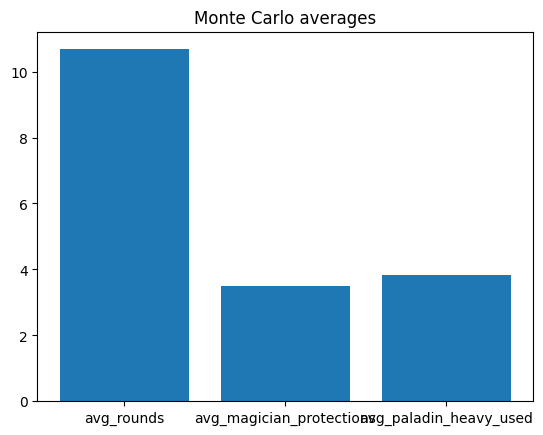

In [ ]:
# 4) Monte Carlo averages plot
def plot_averages(results: dict):
    labels = ["avg_rounds", "avg_magician_protections", "avg_paladin_heavy_used"]
    values = [
        results["avg_rounds"],
        results["avg_magician_protections"],
        results["avg_paladin_heavy_used"]
    ]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Monte Carlo averages")
    plt.show()

plot_averages(results)


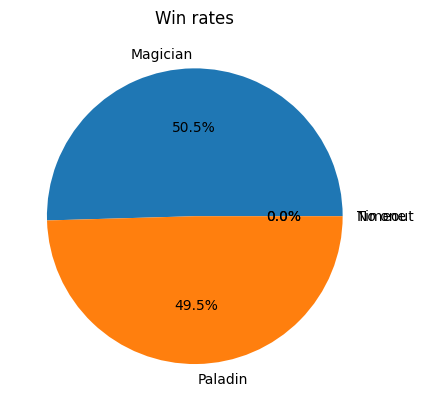

In [ ]:
# 5) Monte Carlo win_rates result
def plot_win_rates(results: dict):
    win_rates = results["win_rates"]
    labels = list(win_rates.keys())
    values = list(win_rates.values())

    plt.figure()
    plt.pie(values, labels=labels, autopct="%1.1f%%")
    plt.title("Win rates")
    plt.show()

plot_win_rates(results)